In [2]:
import joblib
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [3]:
X_test_processed = joblib.load(
    "X_test_processed.pkl"
)

y_test = joblib.load(
    "y_test.pkl"
)

X_train_processed = joblib.load(
    "X_train_processed.pkl"
)

y_train = joblib.load(
    "y_train.pkl"
)

In [4]:
print(X_test_processed.shape)
print(y_test.shape)

(5000, 43)
(5000,)


In [5]:
models = {

    "Logistic Regression": joblib.load(
        "../models/logistic_regression.pkl"
    ),

    "KNN": joblib.load(
        "../models/knn.pkl"
    ),

    "Decision Tree": joblib.load(
        "../models/decision_tree.pkl"
    ),

    "Random Forest": joblib.load(
        "../models/random_forest.pkl"
    ),

    "XGBoost": joblib.load(
        "../models/xgboost.pkl"
    )
}

In [6]:
models.keys()

dict_keys(['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost'])

LogisticRegression

In [7]:
logistic_model = models["Logistic Regression"]

In [8]:
y_pred = logistic_model.predict(
    X_test_processed
)

In [9]:
print("pred",y_pred[:20])

pred [0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1]


In [10]:
print("test",y_test.iloc[:20].values)

test [0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[3381,  285],
       [ 251, 1083]])

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.8928

In [13]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8928
Precision: 0.7916666666666666
Recall: 0.8118440779610195
F1 Score: 0.8016284233900814


In [14]:
y_probability = logistic_model.predict_proba(
    X_test_processed
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

roc_auc

0.9668995289589247

In [15]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

In [16]:
train_sizes, train_scores, validation_scores = learning_curve(
    logistic_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [17]:
train_mean = train_scores.mean(axis=1)

validation_mean = validation_scores.mean(axis=1)

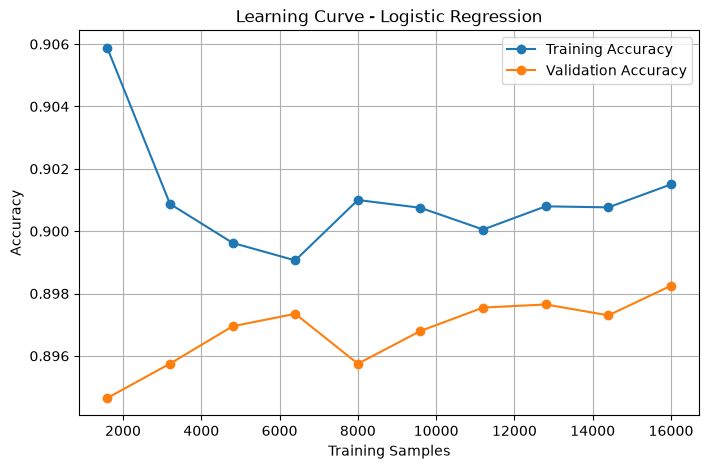

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)


plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve - Logistic Regression")

plt.legend()

plt.grid()

plt.show()

In [81]:
logistic_results = {

    "Model": "Logistic Regrassion",

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1 Score": f1,

    "ROC-AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regrassion',
 'Accuracy': 0.8928,
 'Precision': 0.7916666666666666,
 'Recall': 0.8118440779610195,
 'F1 Score': 0.8016284233900814,
 'ROC-AUC': 0.9668995289589247}

KNN

In [19]:
knn_model = joblib.load(
    "../models/knn.pkl"
)

In [20]:
knn_pred = knn_model.predict(
    X_test_processed
)

In [21]:
print(knn_pred[:20])

print(y_test.iloc[:20].values)

[0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1]
[0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [22]:
knn_cm = confusion_matrix(
    y_test,
    knn_pred
)

knn_cm

array([[3343,  323],
       [ 251, 1083]])

In [23]:
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

knn_accuracy

0.8852

In [24]:
knn_precision = precision_score(
    y_test,
    knn_pred
)

knn_precision

0.7702702702702703

In [25]:
knn_recall = recall_score(
    y_test,
    knn_pred
)

knn_recall

0.8118440779610195

In [26]:
knn_f1 = f1_score(
    y_test,
    knn_pred
)

knn_f1

0.7905109489051095

In [27]:
knn_probability = knn_model.predict_proba(
    X_test_processed
)[:,1]

In [28]:
knn_auc = roc_auc_score(
    y_test,
    knn_probability
)

knn_auc

0.9413653443327437

In [29]:
knn_results = {

    "Model": "KNN",

    "Accuracy": knn_accuracy,

    "Precision": knn_precision,

    "Recall": knn_recall,

    "F1 Score": knn_f1,

    "ROC-AUC": knn_auc
}

knn_results

{'Model': 'KNN',
 'Accuracy': 0.8852,
 'Precision': 0.7702702702702703,
 'Recall': 0.8118440779610195,
 'F1 Score': 0.7905109489051095,
 'ROC-AUC': 0.9413653443327437}

In [30]:
knn_train_sizes, knn_train_scores, knn_validation_scores = learning_curve(
    knn_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

In [31]:
knn_train_mean = knn_train_scores.mean(axis=1)

knn_validation_mean = knn_validation_scores.mean(axis=1)

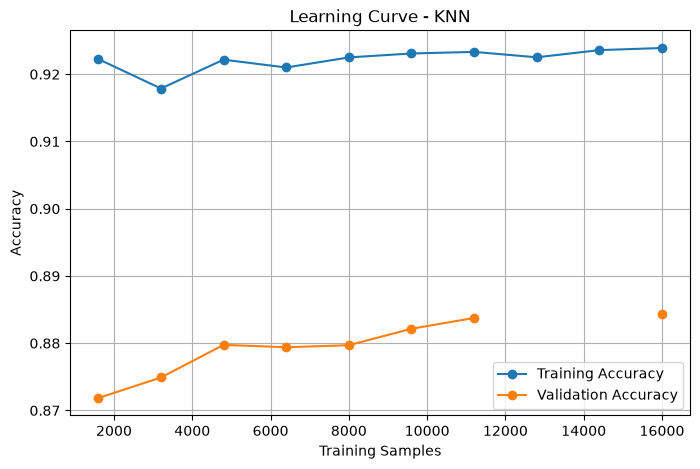

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    knn_train_sizes,
    knn_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    knn_train_sizes,
    knn_validation_mean,
    marker="o",
    label="Validation Accuracy"
)


plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - KNN")

plt.legend()
plt.grid()

plt.show()

Decision Tree

In [33]:
decision_tree_model = joblib.load(
    "../models/decision_tree.pkl"
)

In [34]:
dt_pred = decision_tree_model.predict(
    X_test_processed
)

In [35]:
print(dt_pred[:20])

print(y_test.iloc[:20].values)

[0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0]
[0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [36]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

dt_cm

array([[3335,  331],
       [ 302, 1032]])

In [37]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_accuracy

0.8734

In [38]:
dt_precision = precision_score(
    y_test,
    dt_pred
)

dt_precision

0.7571533382245048

In [39]:
dt_recall = recall_score(
    y_test,
    dt_pred
)

dt_recall

0.7736131934032984

In [40]:
dt_f1 = f1_score(
    y_test,
    dt_pred
)

dt_f1

0.7652947719688543

In [41]:
dt_probability = decision_tree_model.predict_proba(
    X_test_processed
)[:,1]

In [42]:
dt_auc = roc_auc_score(
    y_test,
    dt_probability
)

dt_auc

0.8416620249613327

In [43]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3666
           1       0.76      0.77      0.77      1334

    accuracy                           0.87      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.87      0.87      0.87      5000



In [44]:
dt_train_sizes, dt_train_scores, dt_validation_scores = learning_curve(
    decision_tree_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

In [45]:
dt_train_mean = dt_train_scores.mean(axis=1)

dt_validation_mean = dt_validation_scores.mean(axis=1)

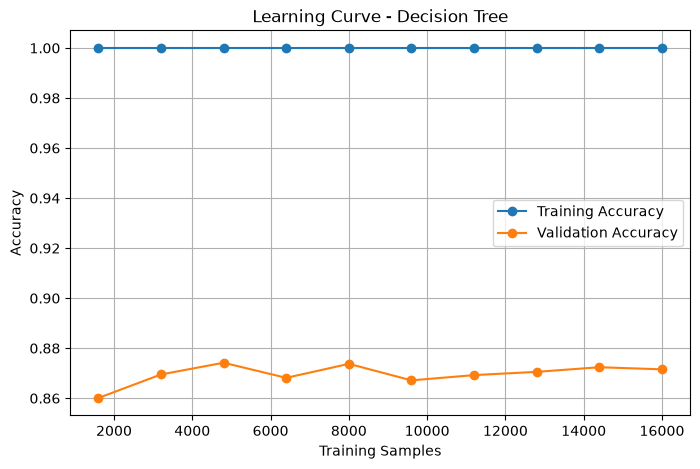

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    dt_train_sizes,
    dt_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    dt_train_sizes,
    dt_validation_mean,
    marker="o",
    label="Validation Accuracy"
)


plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - Decision Tree")

plt.legend()
plt.grid()

plt.show()

In [47]:
dt_results = {

    "Model": "Decision Tree",

    "Accuracy": dt_accuracy,

    "Precision": dt_precision,

    "Recall": dt_recall,

    "F1 Score": dt_f1,

    "ROC-AUC": dt_auc

}

dt_results

{'Model': 'Decision Tree',
 'Accuracy': 0.8734,
 'Precision': 0.7571533382245048,
 'Recall': 0.7736131934032984,
 'F1 Score': 0.7652947719688543,
 'ROC-AUC': 0.8416620249613327}

RAndom Forest

In [49]:
random_forest_model = joblib.load(
    "../models/random_forest.pkl"
)

In [50]:
rf_pred = random_forest_model.predict(
    X_test_processed
)

In [51]:
print(rf_pred[:20])

print(y_test.iloc[:20].values)

[0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1]
[0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [52]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

rf_cm

array([[3371,  295],
       [ 251, 1083]])

In [53]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_accuracy

0.8908

In [54]:
rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_precision

0.785921625544267

In [55]:
rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_recall

0.8118440779610195

In [56]:
rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_f1

0.7986725663716814

In [57]:
rf_probability = random_forest_model.predict_proba(
    X_test_processed
)[:,1]

In [58]:
rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

rf_auc

0.9652922106868007

In [59]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3666
           1       0.79      0.81      0.80      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.87      0.86      5000
weighted avg       0.89      0.89      0.89      5000



In [60]:
rf_train_sizes, rf_train_scores, rf_validation_scores = learning_curve(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

In [61]:
rf_train_mean = rf_train_scores.mean(axis=1)

rf_validation_mean = rf_validation_scores.mean(axis=1)

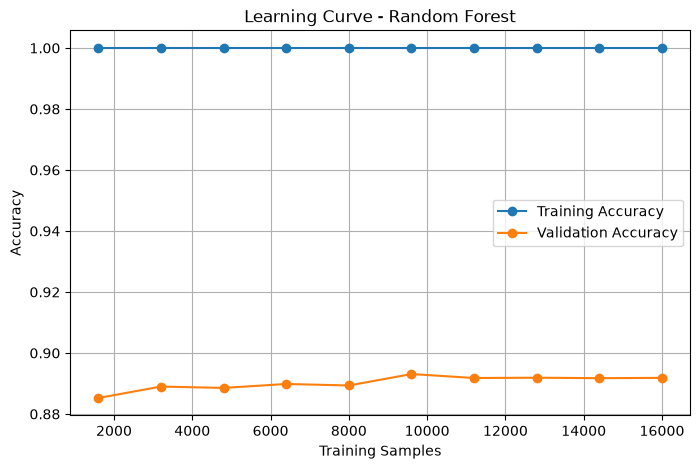

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    rf_train_sizes,
    rf_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    rf_train_sizes,
    rf_validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - Random Forest")

plt.legend()
plt.grid()

plt.show()

In [63]:
rf_results = {

    "Model": "Random Forest",

    "Accuracy": rf_accuracy,

    "Precision": rf_precision,

    "Recall": rf_recall,

    "F1 Score": rf_f1,

    "ROC-AUC": rf_auc

}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8908,
 'Precision': 0.785921625544267,
 'Recall': 0.8118440779610195,
 'F1 Score': 0.7986725663716814,
 'ROC-AUC': 0.9652922106868007}

XGBoost

In [64]:
xgb_model = joblib.load(
    "../models/xgboost.pkl"
)

In [65]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

print(xgb_pred[:20])
print(y_test.iloc[:20].values)

[0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1]
[0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1]


In [66]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

xgb_cm

array([[3364,  302],
       [ 254, 1080]])

In [67]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_accuracy

0.8888

In [68]:
xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_precision

0.7814761215629522

In [69]:
xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_recall

0.8095952023988006

In [70]:
xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_f1

0.7952871870397643

In [71]:
xgb_probability = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [72]:
xgb_auc = roc_auc_score(
    y_test,
    xgb_probability
)

xgb_auc

0.9622586415466571

In [73]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3666
           1       0.78      0.81      0.80      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.89      0.89      0.89      5000



In [74]:
xgb_train_sizes, xgb_train_scores, xgb_validation_scores = learning_curve(
    xgb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [75]:
xgb_train_mean = xgb_train_scores.mean(axis=1)

xgb_validation_mean = xgb_validation_scores.mean(axis=1)

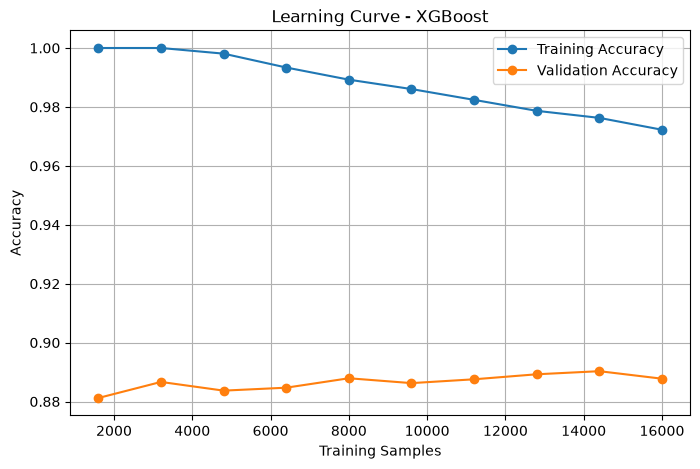

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    xgb_train_sizes,
    xgb_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    xgb_train_sizes,
    xgb_validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - XGBoost")

plt.legend()
plt.grid()

plt.show()

In [77]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_auc
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8888,
 'Precision': 0.7814761215629522,
 'Recall': 0.8095952023988006,
 'F1 Score': 0.7952871870397643,
 'ROC-AUC': 0.9622586415466571}

COMPARISION TABLE


In [82]:
import pandas as pd

results = [
    logistic_results,
    knn_results,
    dt_results,
    rf_results,
    xgb_results
]

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regrassion,0.8928,0.791667,0.811844,0.801628,0.966900
1,KNN,0.8852,0.770270,0.811844,0.790511,0.941365
2,Decision Tree,0.8734,0.757153,0.773613,0.765295,0.841662
3,Random Forest,0.8908,0.785922,0.811844,0.798673,0.965292
4,XGBoost,0.8888,0.781476,0.809595,0.795287,0.962259


In [83]:
comparison_display = comparison_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_display[metrics] = (
    comparison_display[metrics] * 100
).round(2)

comparison_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regrassion,89.28,79.17,81.18,80.16,96.69
1,KNN,88.52,77.03,81.18,79.05,94.14
2,Decision Tree,87.34,75.72,77.36,76.53,84.17
3,Random Forest,89.08,78.59,81.18,79.87,96.53
4,XGBoost,88.88,78.15,80.96,79.53,96.23


In [85]:
comparison_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)